In [1]:
import sys
import os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

from hyperQUAD.quad_control import HyperQuadControl
import numpy as np
from joblib import Parallel, delayed
import time 

import matplotlib.pyplot as plt

In [2]:
ham_args = (1,)

def LZ_hamiltonian(z, *ham_args):
    x = ham_args[0]
    
    ham = np.array([[z, x],
                    [x, -z]])
    
    return ham

# partial_ham = np.array([[1, 0],
#                         [0, -1]])

def partial_ham(*ham_args):
    return np.array([[1, 0],
                     [0, -1]])


di_LZ = HyperQuadControl(
    
    hamiltonian=LZ_hamiltonian,
    partial_hamiltonian=partial_ham,
    control_init=-10,
    control_final=10,
    ham_args=ham_args,
    initial_state=0,
    final_state=1,
    
)

ad_LZ = HyperQuadControl(
    
    hamiltonian=LZ_hamiltonian,
    partial_hamiltonian=partial_ham,
    control_init=-10,
    control_final=10,
    ham_args=ham_args,
    initial_state=0,
    final_state=0,
    
)

Fidelity analysis (Adiabatic and Diabatic)

In [3]:
def process_alpha_beta(model, sweep, alpha, beta, n_jobs_inner):
    model.update_params(alpha=alpha, beta=beta)
    
    s, control_sol = model.compute_optimal_pulse()
    fids = model.fidelity_sweep_parallel(sweep, infidelity=True, n_jobs=n_jobs_inner) #Note that this is the infidelity
    
    return fids, (alpha, beta), (s, control_sol)


def data_gen_parallel(model, sweep, alpha_beta_list, n_jobs_outer, n_jobs_inner):
    results = Parallel(n_jobs=n_jobs_outer)(
        delayed(process_alpha_beta)(model, sweep, alpha, beta, n_jobs_inner) for alpha, beta in alpha_beta_list
    )
    
    fidelities, labels, plots = zip(*results)
    return list(fidelities), list(labels), list(plots)

In [4]:
alpha_beta_list_di = [(-2, -4), (-2, -2), (2, -2)]
alpha_beta_list_ad = [(2, -2), (2, 2), (2, 4)]
sweep = {'pulse_time': np.linspace(.01, 10, 500)} 

In [5]:
fidelities_ad = []
labels_ad = []
plots_ad = []
n_jobs = 50
for alpha, beta in alpha_beta_list_ad:
	fids, label, plot = process_alpha_beta(ad_LZ, sweep, alpha, beta, n_jobs_inner=n_jobs)
	fidelities_ad.append(fids)
	labels_ad.append(label)
	plots_ad.append(plot)

Parallel sweeping pulse_time: 100%|██████████| 500/500 [00:30<00:00, 16.43it/s]


In [6]:
fidelities_di = []
labels_di = []
plots_di = []
n_jobs = 50
for alpha, beta in alpha_beta_list_di:
	fids, label, plot = process_alpha_beta(di_LZ, sweep, alpha, beta, n_jobs_inner=n_jobs)
	fidelities_di.append(fids)
	labels_di.append(label)
	plots_di.append(plot)

Parallel sweeping pulse_time: 100%|██████████| 500/500 [00:27<00:00, 18.49it/s]


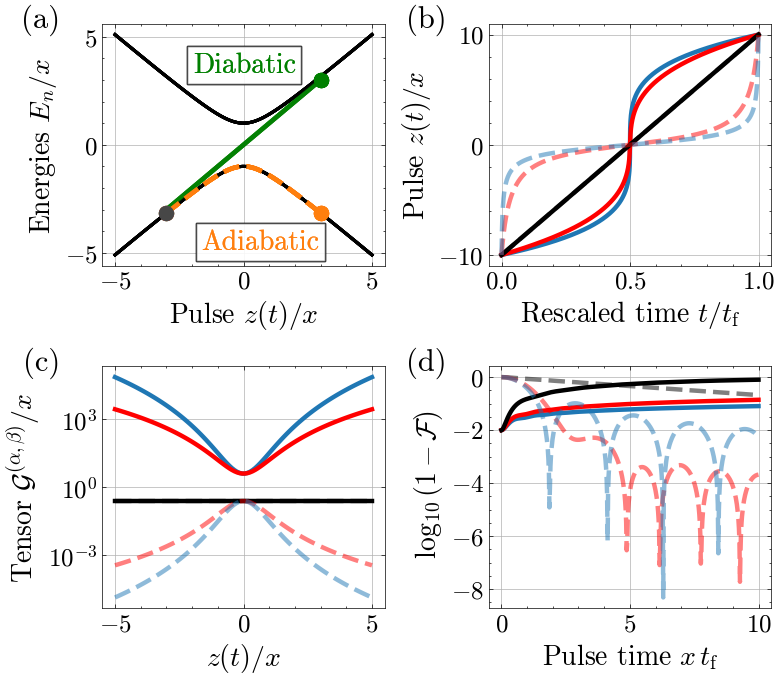

In [7]:
import scienceplots

# plt.style.use(['default'])
plt.style.use(['science','no-latex'])

# Combine datasets
all_data = [
    ("diabatic", plots_di, fidelities_di, labels_di),
    ("adiabatic", plots_ad, fidelities_ad, labels_ad),
]

list_sweep = list(sweep.values())[0]

# Assign fixed colors to |n+|
color_list = ['black', 'red', 'tab:blue']
unique_nplus = sorted(set(
    abs((alpha + beta) / 2)
    for _, _, _, labels in all_data
    for alpha, beta in labels
))
nplus_to_color = {n: color_list[i] for i, n in enumerate(unique_nplus)}

fig, axs = plt.subplots(2, 2, figsize=(8, 7))

linewidth = 3.2
fontsize_axes = 20


# Loop through data
for tag, plots, fidelities, labels in all_data:
    linestyle = 'dashed' if tag == "adiabatic" else '-'
    alpha_style = 0.5 if tag == "adiabatic" else 1

    for (plot, fid, label) in zip(plots, fidelities, labels):
        alpha, beta = label
        nplus = (alpha + beta) / 2
        abs_nplus = abs(nplus)
        color = nplus_to_color[abs_nplus]
        label_text = fr"{tag}: $n_+ = {nplus:.0f}$"

        # Plot eigenenergies
        x = np.linspace(-5,5,100)
        x_plot = np.linspace(-3,3,100)
        axs[0,0].plot(x, np.sqrt(1+x**2),linewidth=linewidth-1, color='black')
        axs[0,0].plot(x, -np.sqrt(1+x**2),linewidth=linewidth-1, color='black')
        axs[0,0].plot(x_plot, 1*x_plot, linewidth=linewidth, color='green', alpha=0.5, label='Diabatic')
        axs[0,0].plot(x_plot, -np.sqrt(1+x_plot**2), linewidth=linewidth, linestyle='dashed', color='tab:orange', alpha=1, label='Adiabatic')
        axs[0,0].set_ylabel(r"Energies $E_n/x$", fontsize=fontsize_axes)
        axs[0,0].set_xlabel(r"Pulse $z(t)/x$", fontsize=fontsize_axes)
        axs[0,0].text(0.32, 0.8, r'Diabatic', transform=axs[0,0].transAxes,
                    color='green', fontsize=20, bbox=dict(facecolor='white', alpha=0.3))
        axs[0,0].text(0.35, 0.07, r'Adiabatic', transform=axs[0,0].transAxes,
                    color='tab:orange', fontsize=20, bbox=dict(facecolor='white', alpha=0.3))
        scatter_size = 100
        axs[0,0].scatter(x_plot[0], -np.sqrt(1+x_plot[0]**2), zorder=2, s=scatter_size)
        axs[0,0].scatter(x_plot[-1], 1*x_plot[-1], color='green', zorder=2, s=scatter_size)
        axs[0,0].scatter(x_plot[-1], -np.sqrt(1+x_plot[-1]**2), color='tab:orange', zorder=2, s=scatter_size)
        
        

        # Plot fidelity
        infid = np.log10(fid)
        axs[1,1].plot(list_sweep, infid, linewidth=linewidth, linestyle=linestyle, alpha=alpha_style, color=color, label=label_text)
        axs[1,1].set_ylabel(r"$\;\log_{10}(1 - \mathcal{F})$", fontsize=fontsize_axes)
        axs[1,1].set_xlabel(r"Pulse time $x\,t_\text{f}$", fontsize=fontsize_axes)
        axs[1,1].set_yticks([-8, -6, -4, -2,  0])

        # Plot pulse shape 
        s, control_sol = plot
        axs[0,1].plot(s, control_sol, linewidth=linewidth, linestyle=linestyle, alpha=alpha_style, color=color)
        axs[0,1].set_ylabel(r"Pulse $z(t)/x$", fontsize=fontsize_axes)
        axs[0,1].set_xlabel(r"Rescaled time $t/t_\text{f}$", fontsize=fontsize_axes)

        # Plot diad tensor
        z = np.linspace(-5,5,100)
        axs[1,0].plot(z, 1/2**alpha * (1+z**2)**(-nplus), linewidth=linewidth, linestyle=linestyle,alpha=alpha_style, color=color)
        axs[1,0].set_yscale('log')
        axs[1,0].set_ylabel(r"Tensor $\mathcal{G}^{(\alpha,\beta)}/x$", fontsize=fontsize_axes)
        axs[1,0].set_xlabel(r"$z(t)/x$", fontsize=fontsize_axes)

        

for i,j in [[0,0],[0,1],[1,0],[1,1]]:
    axs[i,j].tick_params(labelsize=18)
    axs[i,j].grid(True)

for i, ax in enumerate(axs.flat):
    idx_list_flat = [] 
    offset_y = 0.26 if i in idx_list_flat else 0.0  
    ax.text(-0.15, 1.08 + offset_y, f'({chr(97 + i)})',
            transform=ax.transAxes,
            fontsize=22, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.show()

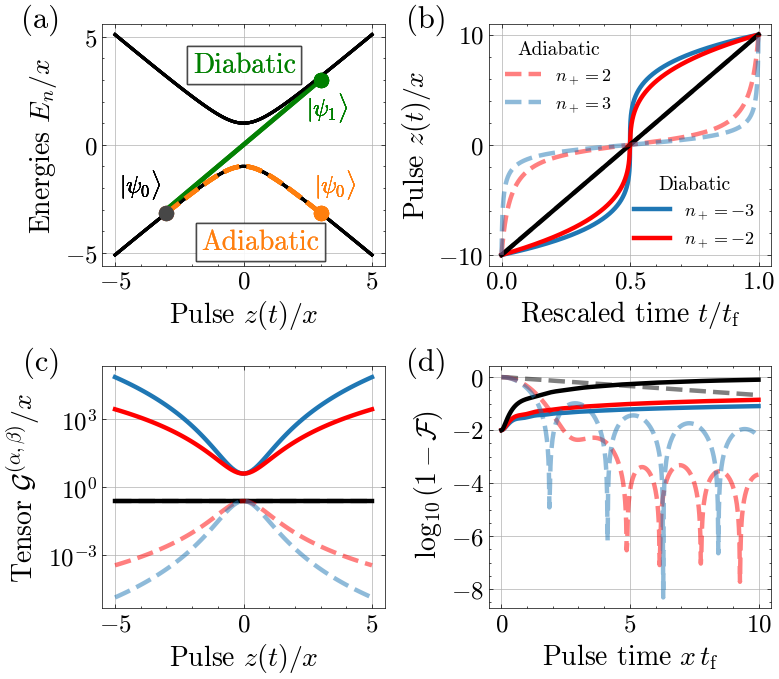

In [7]:
import scienceplots

# plt.style.use(['default'])
plt.style.use(['science', 'no-latex'])

# Combine datasets
all_data = [
    ("diabatic", plots_di, fidelities_di, labels_di),
    ("adiabatic", plots_ad, fidelities_ad, labels_ad),
]

list_sweep = list(sweep.values())[0]

# Assign fixed colors to |n+|
color_list = ['black', 'red', 'tab:blue']
unique_nplus = sorted(set(
    abs((alpha + beta) / 2)
    for _, _, _, labels in all_data
    for alpha, beta in labels
))
nplus_to_color = {n: color_list[i] for i, n in enumerate(unique_nplus)}

fig, axs = plt.subplots(2, 2, figsize=(8, 7))

linewidth = 3.2
fontsize_axes = 20

# --- LEGEND STORAGE FOR PULSE SHAPE PANEL ---
handles_pos, labels_pos = [], []
handles_neg, labels_neg = [], []
seen_labels = set()

# Loop through data
for tag, plots, fidelities, labels in all_data:
    linestyle = 'dashed' if tag == "adiabatic" else '-'
    alpha_style = 0.5 if tag == "adiabatic" else 1

    for (plot, fid, label) in zip(plots, fidelities, labels):
        alpha, beta = label
        nplus = (alpha + beta) / 2
        abs_nplus = abs(nplus)
        color = nplus_to_color[abs_nplus]
        label_text = fr"$n_+ = {nplus:.0f}$"

        # ======================
        # Eigenenergies panel
        # ======================
        x = np.linspace(-5, 5, 100)
        x_plot = np.linspace(-3, 3, 100)
        axs[0,0].plot(x, np.sqrt(1+x**2), linewidth=linewidth-1, color='black')
        axs[0,0].plot(x, -np.sqrt(1+x**2), linewidth=linewidth-1, color='black')
        axs[0,0].plot(x_plot, x_plot, linewidth=linewidth,
                      color='green', alpha=0.5)
        axs[0,0].plot(x_plot, -np.sqrt(1+x_plot**2), linewidth=linewidth,
                      linestyle='dashed', color='tab:orange')
        axs[0,0].set_ylabel(r"Energies $E_n/x$", fontsize=fontsize_axes)
        axs[0,0].set_xlabel(r"Pulse $z(t)/x$", fontsize=fontsize_axes)

        axs[0,0].text(0.32, 0.8, r'Diabatic',
                      transform=axs[0,0].transAxes,
                      color='green', fontsize=20,
                      bbox=dict(facecolor='white', alpha=0.3))
        axs[0,0].text(0.35, 0.07, r'Adiabatic',
                      transform=axs[0,0].transAxes,
                      color='tab:orange', fontsize=20,
                      bbox=dict(facecolor='white', alpha=0.3))

        scatter_size = 100
        axs[0,0].scatter(x_plot[0], -np.sqrt(1+x_plot[0]**2), zorder=2, s=scatter_size)                
        axs[0,0].text(0.06, 0.3, r'$|\psi_\text{0}\rangle$', fontsize=17, color='black', transform=axs[0,0].transAxes)

        axs[0,0].scatter(x_plot[-1], x_plot[-1], color='green', zorder=2, s=scatter_size)                 
        axs[0,0].text(0.72, 0.62, r'$|\psi_\text{1}\rangle$', fontsize=17, color='green', transform=axs[0,0].transAxes)

        axs[0,0].scatter(x_plot[-1], -np.sqrt(1+x_plot[-1]**2), color='tab:orange', zorder=2, s=scatter_size)                 
        axs[0,0].text(0.75, 0.3, r'$|\psi_\text{0}\rangle$', fontsize=17, color='tab:orange', transform=axs[0,0].transAxes)

        # ======================
        # Fidelity panel
        # ======================
        infid = np.log10(fid)
        axs[1,1].plot(
            list_sweep, infid,
            linewidth=linewidth,
            linestyle=linestyle,
            alpha=alpha_style,
            color=color
        )
        axs[1,1].set_ylabel(r"$\;\log_{10}(1 - \mathcal{F})$", fontsize=fontsize_axes)
        axs[1,1].set_xlabel(r"Pulse time $x\,t_\text{f}$", fontsize=fontsize_axes)
        axs[1,1].set_yticks([-8, -6, -4, -2, 0])

        # ======================
        # Pulse shape panel (LEGENDS HERE)
        # ======================
        s, control_sol = plot
        line, = axs[0,1].plot(
            s, control_sol,
            linewidth=linewidth,
            linestyle=linestyle,
            alpha=alpha_style,
            color=color
        )

        if label_text not in seen_labels:
            if nplus > 0:
                handles_pos.append(line)
                labels_pos.append(label_text)
            elif nplus < 0:
                handles_neg.append(line)
                labels_neg.append(label_text)
            seen_labels.add(label_text)

        axs[0,1].set_ylabel(r"Pulse $z(t)/x$", fontsize=fontsize_axes)
        axs[0,1].set_xlabel(r"Rescaled time $t/t_\text{f}$", fontsize=fontsize_axes)

        # ======================
        # Tensor panel
        # ======================
        z = np.linspace(-5, 5, 100)
        axs[1,0].plot(
            z, 1/2**alpha * (1+z**2)**(-nplus),
            linewidth=linewidth,
            linestyle=linestyle,
            alpha=alpha_style,
            color=color
        )
        axs[1,0].set_yscale('log')
        axs[1,0].set_ylabel(r"Tensor $\mathcal{G}^{(\alpha,\beta)}/x$", fontsize=fontsize_axes)
        axs[1,0].set_xlabel(r"Pulse $z(t)/x$", fontsize=fontsize_axes)

# ======================
# Add pulse-shape legends
# ======================
if handles_pos:
    leg_pos = axs[0,1].legend(
        handles_pos, labels_pos,
        loc='upper left',
        frameon=False,
        fontsize=13,
        title="Adiabatic",
        title_fontsize=14
    )
    axs[0,1].add_artist(leg_pos)

if handles_neg:
    axs[0,1].legend(
        handles_neg, labels_neg,
        loc='lower right',
        frameon=False,
        fontsize=13,
        title="Diabatic",
        title_fontsize=14
    )

# ======================
# Final formatting
# ======================
for i, j in [[0,0], [0,1], [1,0], [1,1]]:
    axs[i, j].tick_params(labelsize=18)
    axs[i, j].grid(True)

for i, ax in enumerate(axs.flat):
    ax.text(-0.15, 1.08, f'({chr(97 + i)})',
            transform=ax.transAxes,
            fontsize=22, fontweight='bold',
            va='top', ha='right')

plt.tight_layout()
plt.show()
